In [1]:
# ==========================================================
# Imports
# ==========================================================

import pandas as pd
import numpy as np
import gower

from sklearn.impute import KNNImputer

import seaborn as sns
import matplotlib.pyplot as plt


# ==========================================================
# Load files
# ==========================================================

demo = pd.read_csv("SCD_Demographics.csv")
comps = pd.read_csv("SCD_Top10_Complication_Details.csv")
labs = pd.read_csv("lab_measurements_wide_with_units.csv")
geno = pd.read_csv("ALL_481_genotypes_wide.csv")



# ==========================================================
# Convert genotype file:
# variants x participants
#          ↓
# participants x variants
# ==========================================================


# Create variant names

geno["variant_id"] = (
    "chr"
    + geno["CHROM"].astype(str)
    + ":"
    + geno["POS"].astype(str)
    + "_"
    + geno["REF"].astype(str)
    + "_"
    + geno["ALT"].astype(str)
)


# ==========================================================
# Identify participant genotype columns
# ==========================================================

metadata_cols = [
    "CHROM",
    "POS",
    "REF",
    "ALT",
    "variant_id",
    "SOURCE_VCF",
    "ID",
    "QUAL",
    "FILTER",
    "INFO"
]


participant_cols = [
    c for c in geno.columns
    if c not in metadata_cols
]


print("Number of genotype columns:", len(participant_cols))
print(participant_cols[:10])


# Keep all variants

geno2 = geno[
    ["variant_id"] + participant_cols
].copy()


geno2 = geno2.set_index(
    "variant_id"
)


# Transpose

geno_t = geno2.T


geno_t.index.name = "person_id"

geno_t = geno_t.reset_index()


# Convert ID type

geno_t["person_id"] = (
    geno_t["person_id"]
    .astype(int)
)


print("\nGenotype table:")
print(geno_t.shape)



# ==========================================================
# Merge datasets
# ==========================================================

df = demo.merge(
    labs,
    on="person_id",
    how="inner"
)


df = df.merge(
    comps,
    on="person_id",
    how="inner"
)


df = df.merge(
    geno_t,
    on="person_id",
    how="inner"
)


print("\nMerged dataset:")
print(df.shape)

print(
    "Participants:",
    df["person_id"].nunique()
)



# ==========================================================
# Calculate age
# ==========================================================

df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    errors="coerce",
    utc=True
)


df["date_of_birth"] = (
    df["date_of_birth"]
    .dt.tz_localize(None)
)


reference_date = pd.to_datetime(
    "2025-07-01"
)


df["age"] = (
    reference_date - df["date_of_birth"]
).dt.days / 365.25



# ==========================================================
# Rename clinical columns
# ==========================================================

df.rename(columns={

    "sex_at_birth":
    "sex",

    "Systolic blood pressure":
    "systolic_bp",

    "Diastolic blood pressure":
    "diastolic_bp",

    "Heart rate":
    "heart_rate",

    "Hemoglobin F/Hemoglobin.total in Blood":
    "hbf_percent",

    "Leukocytes [#/volume] in Blood by Automated count":
    "wbc",

    "Neutrophils/100 leukocytes in Blood by Automated count":
    "neutrophils",

    "Monocytes/100 leukocytes in Blood by Automated count":
    "monocytes",

    "Basophils/100 leukocytes in Blood by Automated count":
    "basophils",

    "top10_complication_count":
    "complication_count"

}, inplace=True)



# ==========================================================
# Clinical features
# ==========================================================

complication_cols = [

    "dactylitis",
    "restrictive_lung_disease",
    "preeclampsia",
    "sickle_retinopathy",
    "osteomyelitis",
    "aplastic_crisis",
    "liver_cirrhosis",
    "vitreous_haemorrhage",
    "hand_foot_syndrome",
    "pulmonary_hypertension"

]


clinical_features = [

    "age",
    "sex",
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "hbf_percent",
    "wbc",
    "neutrophils",
    "monocytes",
    "basophils",
    "complication_count"

] + complication_cols



# ==========================================================
# Genetic columns
# ==========================================================


genetic_cols = [
    c for c in df.columns
    if c.startswith("chr")
]


print("\nTotal genetic variants:")
print(len(genetic_cols))


print(genetic_cols)



# Hb-related variants as categorical

categorical_genetic = [

    c for c in genetic_cols
    if any(x in c for x in [
        "chr11:5239228",
        "chr11:5242453",
        "chr11:5248569",
        "chr11:5254939"
    ])

]


dosage_genetic = [
    c for c in genetic_cols
    if c not in categorical_genetic
]


print("\nCategorical genetic:")
print(categorical_genetic)


print("\nDosage SNP count:")
print(len(dosage_genetic))



# ==========================================================
# Convert genotype dosage
# ==========================================================


dosage_map = {

    "0|0":0,
    "0|1":1,
    "1|0":1,
    "1|1":2,

    "0/0":0,
    "0/1":1,
    "1/0":1,
    "1/1":2

}


df[dosage_genetic] = (
    df[dosage_genetic]
    .replace(dosage_map)
)



# Convert dosage SNPs numeric

df[dosage_genetic] = (
    df[dosage_genetic]
    .apply(pd.to_numeric, errors="coerce")
)

# ==========================================================
# Handle missing genetic data
# Keep genetic information intact
# ==========================================================

# ----------------------------------------------------------
# Dosage SNPs
# Missing genotype = -1
# Do NOT mean impute genetics
# ----------------------------------------------------------

df[dosage_genetic] = (
    df[dosage_genetic]
    .apply(pd.to_numeric, errors="coerce")
)


df[dosage_genetic] = (
    df[dosage_genetic]
    .fillna(-1)
)


print("\nDosage SNP missing after handling:")
print(
    df[dosage_genetic]
    .isna()
    .sum()
)



# ----------------------------------------------------------
# Categorical Hb-related variants
# Missing genotype = "Missing"
# ----------------------------------------------------------

for col in categorical_genetic:

    df[col] = (
        df[col]
        .fillna("Missing")
        .astype(str)
    )


print("\nCategorical SNP missing after handling:")
print(
    df[categorical_genetic]
    .isna()
    .sum()
)

# ==========================================================
# Fix sex variable (numeric codes → categorical)
# ==========================================================

df["sex"] = df["sex"].astype("category")
df["sex"] = df["sex"].cat.add_categories(["Missing"])
df["sex"] = df["sex"].fillna("Missing")

# Optional: map numeric codes to labels
# sex_map = {0: "Female", 1: "Male"}
# df["sex"] = df["sex"].map(sex_map).astype("category")


# ==========================================================
# Impute clinical variables ONLY
# ==========================================================

clinical_numeric = [
    c for c in clinical_features
    if c != "sex"
]


print("\nClinical missing before imputation:")
print(
    df[clinical_numeric]
    .isna()
    .sum()
    .sort_values(ascending=False)
)


clinical_imputer = KNNImputer(
    
    n_neighbors=5,
    weights="uniform"
)

df[clinical_numeric] = clinical_imputer.fit_transform(
    df[clinical_numeric]
)


print("\nClinical missing after imputation:")
print(
    df[clinical_numeric]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

# ==========================================================
# Final features
# ==========================================================

features = (

    clinical_features
    +
    categorical_genetic
    +
    dosage_genetic

)


print("\nFinal features:")
print(len(features))


X = df[features].copy()



# Convert categorical variables

for col in categorical_genetic + ["sex"]:

    X[col] = X[col].astype(str)



print("\nFinal Gower input:")
print(X.shape)


print(
    "Remaining missing:",
    X.isna().sum().sum()
)



# ==========================================================
# Gower distance
# ==========================================================

gower_dist = gower.gower_matrix(X)


print("\nGower matrix:")
print(gower_dist.shape)

Number of genotype columns: 481
['1006406', '1010745', '1016320', '1020248', '1031989', '1039945', '1039976', '1044156', '1044197', '1044476']

Genotype table:
(481, 22)

Merged dataset:
(481, 58)
Participants: 481

Total genetic variants:
21
['chrchr1:100718269_T_C', 'chrchr11:5239228_T_C', 'chrchr11:5242453_C_T', 'chrchr11:5248569_A_C', 'chrchr11:5248569_A_T', 'chrchr11:5254939_G_A', 'chrchr19:44908684_T_C', 'chrchr19:44908822_C_A', 'chrchr19:44908822_C_T', 'chrchr2:60487726_A_C', 'chrchr2:60490908_T_G', 'chrchr2:60498316_G_A', 'chrchr2:60498316_G_C', 'chrchr22:36265860_A_G', 'chrchr22:36265988_T_G', 'chrchr22:36265996_ATAATT_A', 'chrchr22:36265996_ATAATT_GTAATT', 'chrchr6:31575254_G_A', 'chrchr6:135097526_GC_CC', 'chrchr6:135097526_GC_G', 'chrchr6:135097880_T_C']

Categorical genetic:
['chrchr11:5239228_T_C', 'chrchr11:5242453_C_T', 'chrchr11:5248569_A_C', 'chrchr11:5248569_A_T', 'chrchr11:5254939_G_A']

Dosage SNP count:
16

Dosage SNP missing after handling:
chrchr1:100718269_T_C 

/tmp/ipykernel_1147/282505189.py:323: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(dosage_map)



Clinical missing after imputation:
age                         0
systolic_bp                 0
diastolic_bp                0
heart_rate                  0
hbf_percent                 0
wbc                         0
neutrophils                 0
monocytes                   0
basophils                   0
complication_count          0
dactylitis                  0
restrictive_lung_disease    0
preeclampsia                0
sickle_retinopathy          0
osteomyelitis               0
aplastic_crisis             0
liver_cirrhosis             0
vitreous_haemorrhage        0
hand_foot_syndrome          0
pulmonary_hypertension      0
dtype: int64

Final features:
42

Final Gower input:
(481, 42)
Remaining missing: 0

Gower matrix:
(481, 481)



Running K = 2
K = 2 Silhouette = 0.094

Running K = 3
K = 3 Silhouette = 0.102

Running K = 4
K = 4 Silhouette = 0.109

Best number of clusters: 4
Best silhouette score: 0.10865384

Mean complication count by cluster:
Cluster
0    0.246154
1    0.304348
2    0.301724
3    0.250000
Name: complication_count, dtype: float64
Cluster  Phenotype_Label            
1        Severe phenotype               184
2        Moderately Severe phenotype    116
3        Intermediate phenotype         116
0        Mild phenotype                  65
Name: count, dtype: int64


/opt/conda/envs/jupyter/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/envs/jupyter/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


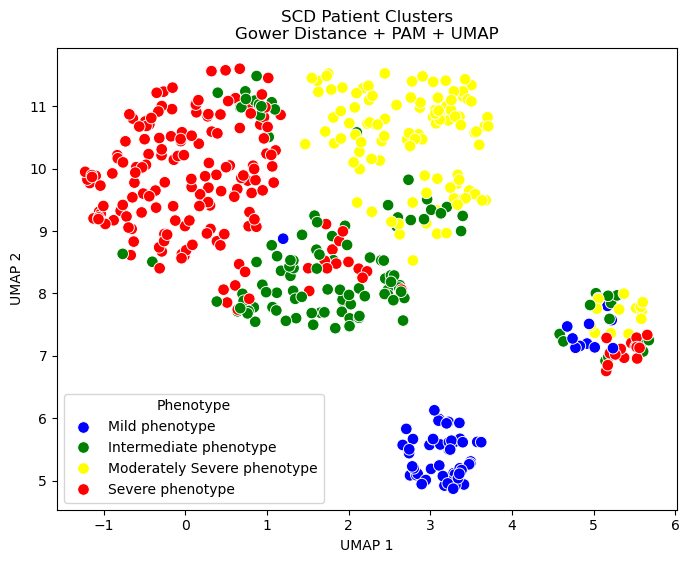

===== Numeric Clinical Summary =====


/tmp/ipykernel_1147/987997179.py:167: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Phenotype_Label")[numeric_summary_features]
/tmp/ipykernel_1147/987997179.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Phenotype_Label")[col]
/tmp/ipykernel_1147/987997179.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Phenotype_Label")[col]
/tmp/ipykernel_1147/987997179.py:177: FutureWa

,age,systolic_bp,diastolic_bp,heart_rate,hbf_percent,wbc,neutrophils,monocytes,basophils,complication_count,...,chrchr2:60498316_G_A,chrchr2:60498316_G_C,chrchr22:36265860_A_G,chrchr22:36265988_T_G,chrchr22:36265996_ATAATT_A,chrchr22:36265996_ATAATT_GTAATT,chrchr6:31575254_G_A,chrchr6:135097526_GC_CC,chrchr6:135097526_GC_G,chrchr6:135097880_T_C
Phenotype_Label,,,,,,,,,,,,,,,,,,,,,
Mild phenotype,48.66,127.50,79.07,78.21,4.45,8.52,58.78,7.52,0.72,0.25,...,0.0,0.95,0.58,0.58,0.00,0.0,0.22,0.03,0.0,0.17
Intermediate phenotype,43.74,122.05,76.13,81.29,6.25,8.35,56.74,8.56,0.78,0.25,...,0.0,0.85,0.97,0.97,0.01,0.0,0.25,0.05,0.0,0.15
Moderately Severe phenotype,50.00,126.47,75.58,76.45,6.37,8.91,54.21,8.93,0.76,0.30,...,0.0,0.91,0.29,0.28,0.00,0.0,0.22,0.05,0.0,0.11
Severe phenotype,51.90,125.45,76.98,78.72,4.90,26.31,55.40,7.75,0.71,0.30,...,0.0,0.83,0.15,0.14,0.00,0.0,0.24,0.05,0.0,0.10


===== Genetic Frequency Summary =====


,Phenotype_Label,chrchr11:5239228_T_C,Percent,Feature,chrchr11:5242453_C_T,chrchr11:5248569_A_C,chrchr11:5248569_A_T,chrchr11:5254939_G_A
0,Mild phenotype,0|0,70.8,chrchr11:5239228_T_C,NaN,NaN,NaN,NaN
1,Mild phenotype,0|1,21.5,chrchr11:5239228_T_C,NaN,NaN,NaN,NaN
2,Mild phenotype,1|0,7.7,chrchr11:5239228_T_C,NaN,NaN,NaN,NaN
3,Mild phenotype,1|1,0.0,chrchr11:5239228_T_C,NaN,NaN,NaN,NaN
4,Intermediate phenotype,0|0,62.1,chrchr11:5239228_T_C,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
63,Moderately Severe phenotype,NaN,0.0,chrchr11:5254939_G_A,NaN,NaN,NaN,1|0
64,Severe phenotype,NaN,90.2,chrchr11:5254939_G_A,NaN,NaN,NaN,0|0
65,Severe phenotype,NaN,8.2,chrchr11:5254939_G_A,NaN,NaN,NaN,0|1
66,Severe phenotype,NaN,1.6,chrchr11:5254939_G_A,NaN,NaN,NaN,1|1



Finished successfully


In [2]:
# ==========================================================
# Imports for clustering and visualisation
# ==========================================================

import numpy as np
import pandas as pd

from pyclustering.cluster.kmedoids import kmedoids

from sklearn.metrics import silhouette_score
import umap.umap_ as umap   # works with numpy 2.x

import seaborn as sns
import matplotlib.pyplot as plt



# ==========================================================
# Test different numbers of clusters
# ==========================================================

silhouette_results = {}
cluster_results = {}

for k in [2, 3, 4]:

    print("\nRunning K =", k)

    initial_medoids = list(range(k))

    model = kmedoids(
        gower_dist.tolist(),
        initial_medoids,
        data_type="distance_matrix"
    )

    model.process()
    clusters = model.get_clusters()

    labels = np.zeros(len(df), dtype=int)

    for cluster_id, cluster in enumerate(clusters):
        for patient in cluster:
            labels[patient] = cluster_id

    score = silhouette_score(
        gower_dist,
        labels,
        metric="precomputed"
    )

    silhouette_results[k] = score
    cluster_results[k] = labels

    print("K =", k, "Silhouette =", round(score, 3))



# ==========================================================
# Select best K
# ==========================================================

best_k = max(silhouette_results, key=silhouette_results.get)

print("\nBest number of clusters:", best_k)
print("Best silhouette score:", silhouette_results[best_k])

df["Cluster"] = cluster_results[best_k]


# ==========================================================
# Phenotype labelling
# ==========================================================

cluster_means = df.groupby("Cluster")["complication_count"].mean()

print("\nMean complication count by cluster:")
print(cluster_means)

if best_k == 2:

    if cluster_means.iloc[0] < cluster_means.iloc[1]:
        label_map = {0: "Mild phenotype", 1: "Severe phenotype"}
    else:
        label_map = {0: "Severe phenotype", 1: "Mild phenotype"}

else:
    severity_order = cluster_means.sort_values().index.tolist()

    labels = [
        "Mild phenotype",
        "Intermediate phenotype",
        "Moderately Severe phenotype",
        "Severe phenotype"
    ]

    label_map = dict(zip(severity_order, labels[:best_k]))

df["Phenotype_Label"] = df["Cluster"].map(label_map)

print(df[["Cluster", "Phenotype_Label"]].value_counts())

# Enforce correct ordered categories
df["Phenotype_Label"] = pd.Categorical(
    df["Phenotype_Label"],
    categories=[
        "Mild phenotype",
        "Intermediate phenotype",
        "Moderately Severe phenotype",
        "Severe phenotype"
    ],
    ordered=True
)

# ==========================================================
# UMAP visualisation (Gower distance)
# ==========================================================

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="precomputed",
    random_state=42
)

coords_umap = umap_model.fit_transform(gower_dist)

df["UMAP1"] = coords_umap[:, 0]
df["UMAP2"] = coords_umap[:, 1]

phenotype_palette = {
    "Severe phenotype": "red",
    "Moderately Severe phenotype": "yellow",
    "Intermediate phenotype": "green",
    "Mild phenotype": "blue"
}

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="UMAP1",
    y="UMAP2",
    hue="Phenotype_Label",
    s=70,
    palette=phenotype_palette
)

plt.title("SCD Patient Clusters\nGower Distance + PAM + UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Phenotype")
plt.show()



# ==========================================================
# Combined cluster summary
# ==========================================================

numeric_summary_features = [
    c for c in features
    if pd.api.types.is_numeric_dtype(df[c])
]

numeric_summary = (
    df.groupby("Phenotype_Label")[numeric_summary_features]
    .mean()
    .round(2)
)

categorical_summary_list = []

for col in categorical_genetic:

    temp = (
        df.groupby("Phenotype_Label")[col]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename("Percent")
        .reset_index()
    )

    temp["Feature"] = col
    categorical_summary_list.append(temp)

categorical_summary = pd.concat(
    categorical_summary_list,
    ignore_index=True
)

print("===== Numeric Clinical Summary =====")
display(numeric_summary)

print("===== Genetic Frequency Summary =====")
display(categorical_summary)



# ==========================================================
# Save outputs
# ==========================================================

numeric_summary.to_csv("cluster_numeric_summary.impute.csv")
categorical_summary.to_csv("cluster_genetic_frequency_summary.impute.csv", index=False)

df.to_csv("SCD_clustering_results_genetic.impute.csv", index=False)

np.save("gower_distance_matrix.impute.npy", gower_dist)

print("\nFinished successfully")

In [3]:
blob = df[(df["UMAP1"] < -5) | (df["UMAP1"] > 5)]


In [4]:
blob[numeric_summary_features].mean().round(2)

age                                 48.52
systolic_bp                        124.91
diastolic_bp                        75.34
heart_rate                          77.61
hbf_percent                          5.48
wbc                                  9.59
neutrophils                         57.33
monocytes                            8.10
basophils                            0.69
complication_count                   0.33
dactylitis                           0.00
restrictive_lung_disease             0.00
preeclampsia                         0.00
sickle_retinopathy                   0.00
osteomyelitis                        0.02
aplastic_crisis                      0.02
liver_cirrhosis                      0.05
vitreous_haemorrhage                 0.02
hand_foot_syndrome                   0.00
pulmonary_hypertension               0.21
chrchr1:100718269_T_C                0.57
chrchr19:44908684_T_C                0.38
chrchr19:44908822_C_A                0.00
chrchr19:44908822_C_T             

In [5]:
blob[categorical_genetic].apply(lambda x: x.value_counts(normalize=True).round(2))


,chrchr11:5239228_T_C,chrchr11:5242453_C_T,chrchr11:5248569_A_C,chrchr11:5248569_A_T,chrchr11:5254939_G_A
0|0,0.74,NaN,NaN,1.0,NaN
0|1,NaN,1.0,0.14,NaN,1.0
1|0,0.24,NaN,NaN,NaN,NaN
1|1,0.02,NaN,0.86,NaN,NaN


In [6]:
blob["Phenotype_Label"].value_counts()

Phenotype_Label
Severe phenotype               15
Moderately Severe phenotype    12
Intermediate phenotype         10
Mild phenotype                  5
Name: count, dtype: int64

In [7]:
genetic_summary = (
    df.groupby("Phenotype_Label")[categorical_genetic]
    .agg(lambda x: x.value_counts(normalize=True).mul(100).round(1))
)

genetic_summary


/tmp/ipykernel_1147/4096077130.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Phenotype_Label")[categorical_genetic]


,chrchr11:5239228_T_C,chrchr11:5242453_C_T,chrchr11:5248569_A_C,chrchr11:5248569_A_T,chrchr11:5254939_G_A
Phenotype_Label,,,,,
Mild phenotype,"[70.8, 21.5, 7.7]","[81.5, 16.9, 1.5]","[89.2, 10.8]",100.0,"[81.5, 16.9, 1.5]"
Intermediate phenotype,"[62.1, 19.0, 16.4, 2.6]","[87.9, 11.2, 0.9]","[84.5, 8.6, 6.0, 0.9]",100.0,"[87.1, 12.1, 0.9]"
Moderately Severe phenotype,"[70.7, 12.1, 11.2, 6.0]","[87.9, 11.2, 0.9]","[81.0, 8.6, 7.8, 2.6]",100.0,"[87.9, 11.2, 0.9]"
Severe phenotype,"[54.9, 20.1, 17.9, 7.1]","[90.2, 8.2, 1.6]","[84.2, 8.2, 6.5, 1.1]",100.0,"[90.2, 8.2, 1.6]"


In [8]:
genetic_summary = (
    df.groupby("Phenotype_Label")[categorical_genetic]
    .agg(lambda x: x.value_counts(normalize=True).mul(100).round(1))
)

genetic_summary


/tmp/ipykernel_1147/4096077130.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Phenotype_Label")[categorical_genetic]


,chrchr11:5239228_T_C,chrchr11:5242453_C_T,chrchr11:5248569_A_C,chrchr11:5248569_A_T,chrchr11:5254939_G_A
Phenotype_Label,,,,,
Mild phenotype,"[70.8, 21.5, 7.7]","[81.5, 16.9, 1.5]","[89.2, 10.8]",100.0,"[81.5, 16.9, 1.5]"
Intermediate phenotype,"[62.1, 19.0, 16.4, 2.6]","[87.9, 11.2, 0.9]","[84.5, 8.6, 6.0, 0.9]",100.0,"[87.1, 12.1, 0.9]"
Moderately Severe phenotype,"[70.7, 12.1, 11.2, 6.0]","[87.9, 11.2, 0.9]","[81.0, 8.6, 7.8, 2.6]",100.0,"[87.9, 11.2, 0.9]"
Severe phenotype,"[54.9, 20.1, 17.9, 7.1]","[90.2, 8.2, 1.6]","[84.2, 8.2, 6.5, 1.1]",100.0,"[90.2, 8.2, 1.6]"


In [10]:
df.groupby("UMAP_cluster")["Phenotype_Label"].value_counts()

UMAP_cluster  Phenotype_Label            
0             Severe phenotype                15
              Intermediate phenotype          13
              Moderately Severe phenotype     13
              Mild phenotype                  11
1             Severe phenotype               169
              Intermediate phenotype         103
              Moderately Severe phenotype    103
              Mild phenotype                   1
2             Mild phenotype                  53
              Intermediate phenotype           0
              Moderately Severe phenotype      0
              Severe phenotype                 0
Name: count, dtype: int64

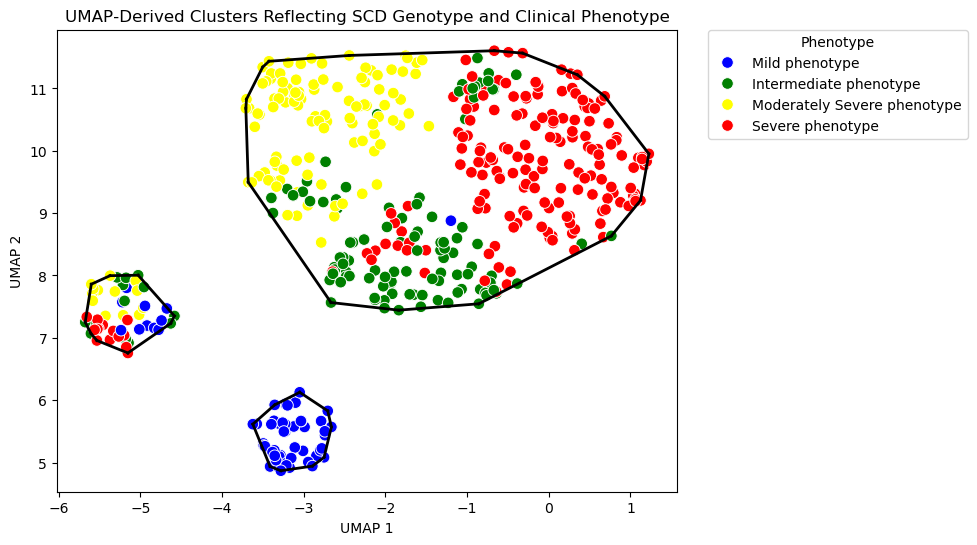

In [15]:
from scipy.spatial import ConvexHull

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x=-df["UMAP1"],
    y=df["UMAP2"],
    hue="Phenotype_Label",
    s=70,
    palette=phenotype_palette
)

for cluster_id in df["UMAP_cluster"].unique():
    cluster_points = df[df["UMAP_cluster"] == cluster_id][["UMAP1", "UMAP2"]].values
    
    # flip UMAP1
    cluster_points[:, 0] = -cluster_points[:, 0]

    if len(cluster_points) > 2:
        hull = ConvexHull(cluster_points)
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0],
                     cluster_points[simplex, 1],
                     "k-", linewidth=2)
plt.title("UMAP‑Derived Clusters Reflecting SCD Genotype and Clinical Phenotype")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
# *** Legend outside the plot ***
plt.legend(
    title="Phenotype",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.
)
plt.show()

In [20]:
umap_clinical = (
    df.groupby("UMAP_cluster")[numeric_summary_features]
    .mean()
    .round(2)
)

umap_clinical

,age,systolic_bp,diastolic_bp,heart_rate,hbf_percent,wbc,neutrophils,monocytes,basophils,complication_count,...,chrchr2:60498316_G_A,chrchr2:60498316_G_C,chrchr22:36265860_A_G,chrchr22:36265988_T_G,chrchr22:36265996_ATAATT_A,chrchr22:36265996_ATAATT_GTAATT,chrchr6:31575254_G_A,chrchr6:135097526_GC_CC,chrchr6:135097526_GC_G,chrchr6:135097880_T_C
UMAP_cluster,,,,,,,,,,,,,,,,,,,,,
0,48.56,123.82,75.21,77.91,5.65,9.42,57.63,8.17,0.66,0.33,...,0.0,0.92,0.50,0.46,0.0,0.0,0.17,0.04,0.0,0.15
1,48.93,124.66,76.44,78.91,5.70,17.17,55.25,8.31,0.75,0.28,...,0.0,0.86,0.43,0.43,0.0,0.0,0.25,0.05,0.0,0.12
2,50.29,129.97,80.18,78.19,4.08,8.54,58.73,7.47,0.72,0.26,...,0.0,0.92,0.45,0.45,0.0,0.0,0.21,0.04,0.0,0.13


In [21]:
umap_clinical.to_csv("umap_cluster_clinical_summary.impute.csv")

In [22]:
umap_genetic = (
    df.groupby("UMAP_cluster")[categorical_genetic]
    .agg(lambda x: x.value_counts(normalize=True).mul(100).round(1))
)

umap_genetic

,chrchr11:5239228_T_C,chrchr11:5242453_C_T,chrchr11:5248569_A_C,chrchr11:5248569_A_T,chrchr11:5254939_G_A
UMAP_cluster,,,,,
0,"[69.2, 28.8, 1.9]",100.0,"[86.5, 13.5]",100.0,100.0
1,"[60.6, 17.3, 16.2, 5.9]","[98.4, 1.6]","[83.5, 8.2, 6.6, 1.6]",100.0,"[98.1, 1.6, 0.3]"
2,"[69.8, 26.4, 3.8]",100.0,"[86.8, 13.2]",100.0,100.0


In [23]:
umap_genetic.to_csv("umap_cluster_genetic_summary.impute.csv")

In [24]:
df.groupby("UMAP_cluster")["Phenotype_Label"].value_counts()

UMAP_cluster  Phenotype_Label            
0             Severe phenotype                15
              Intermediate phenotype          13
              Moderately Severe phenotype     13
              Mild phenotype                  11
1             Severe phenotype               169
              Intermediate phenotype         103
              Moderately Severe phenotype    103
              Mild phenotype                   1
2             Mild phenotype                  53
              Intermediate phenotype           0
              Moderately Severe phenotype      0
              Severe phenotype                 0
Name: count, dtype: int64

In [25]:
umap_pheno_counts = (
    df.groupby("UMAP_cluster")["Phenotype_Label"]
      .value_counts()
      .rename("Count")
      .reset_index()
)
umap_pheno_counts.to_csv("umap_cluster_phenotype_counts.impute.csv", index=False)